In [1]:
using IonSim
using QuantumOptics
using PyPlot

In [2]:
# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 1e6 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
ϵ_vec = (x̂ + ŷ) / √2

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
# transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)

println("Transition Wavelength: ", transition_λ, " m")


# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize(ion["g"] + ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:50.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Transition Wavelength: 7.29147e-7 m
Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 1.29858e-6  2.0481e-6   3.1493e-6    …  3.15316e-6   2.05045e-6  1.29998e-6
 2.15722e-6  3.36492e-6  5.11279e-6      5.11852e-6   3.36845e-6  2.15935e-6
 3.5155e-6   5.42136e-6  8.13605e-6      8.14413e-6   5.42638e-6  3.51856e-6
 5.62256e-6  8.56942e-6  1.26967e-5      1.27073e-5   8.57613e-6  5.62671e-6
 8.82978e-6  1.32964e-5  1.94415e-5      1.94541e-5   1.33045e-5  8.83492e-6
 1.36229e-5  2.02634e-5  2.92286e-5   …  2.92411e-5   2.02717e-5  1.36284e-5
 2.06614e-5  3.03513e-5  4.31767e-5      4.31838e-5   3.03567e-5  2.06655e-5
 3.0825e-5   4.47148e-5  6.27211e-5      6.27126e-5   4.4711e-5   3.08239e-5
 4.52699e-5  6.48469e-5  8.96833e-5      8.964e-5     6.48221e-5  4.52566e-5
 6.54954e-5  9.26568e-5  0.000126356     0.000126246  9.25905e-5  6.54574e-5
 ⋮                                    ⋱                           ⋮
 4.52566e-5  6.48221e-5  8.964e-5        8.96833e-5   6.48469e-5  4.52699e-5
 3.08239e-5  4.4711e-5   6.27126e-5      6.27211e-5   4.47148e

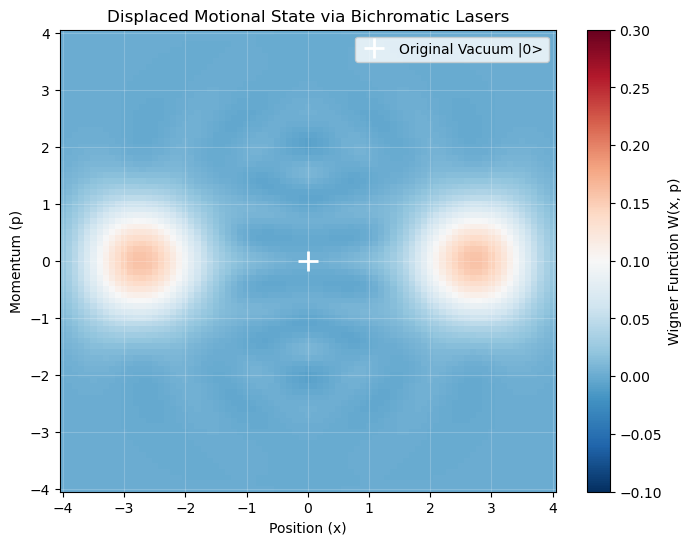

In [3]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [4]:
# 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.5im+0.5

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = I_spin ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * sol[end]

final_state = displaced_final_state

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec) 

81×81 Matrix{Float64}:
 5.28272e-6   8.62251e-6   1.37784e-5   …  2.5735e-5    1.59831e-5
 8.40629e-6   1.35788e-5   2.14652e-5      4.19579e-5   2.63343e-5
 1.30701e-5   2.08828e-5   3.26378e-5      6.6936e-5    4.24768e-5
 1.98552e-5   3.13614e-5   4.84303e-5      0.000104503  6.70853e-5
 2.94705e-5   4.59893e-5   7.01257e-5      0.000159696  0.000103761
 4.27379e-5   6.58486e-5   9.90712e-5   …  0.000238913  0.000157207
 6.05542e-5   9.2052e-5    0.000136542     0.000350003  0.000233373
 8.38248e-5   0.000125627  0.000183555     0.000502232  0.000339547
 0.000113367  0.000167359  0.000240635     0.000706113  0.000484359
 0.000149788  0.000217612  0.00030757      0.000973058  0.000677672
 ⋮                                      ⋱               ⋮
 5.8474e-5    8.40605e-5   0.000117513     0.000821545  0.000553084
 4.25962e-5   6.20643e-5   8.79925e-5      0.000562681  0.000374954
 3.04262e-5   4.49268e-5   6.45938e-5      0.000378549  0.00024971
 2.12995e-5   3.18652e-5   4.64509e-5   

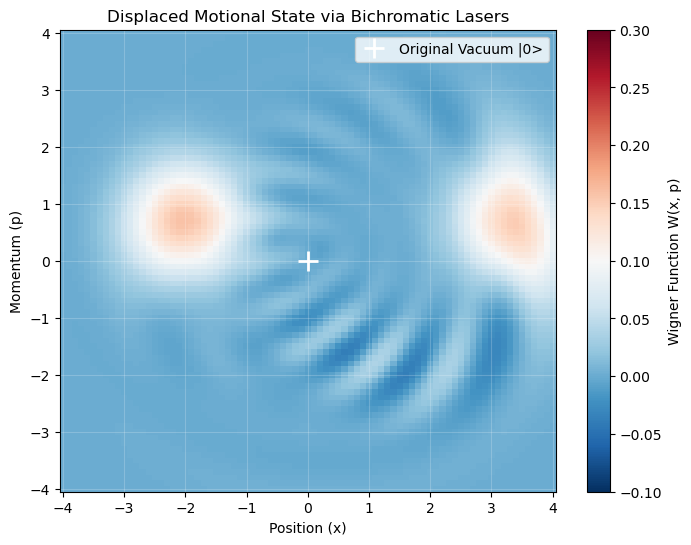

In [5]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [6]:
# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 1e6 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
# transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)


# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize(ion["g"] - im * ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:50.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 5.62054e-7  8.98128e-7  1.40278e-6  2.14164e-6  …  3.22727e-6   2.05289e-6
 9.00159e-7  1.4226e-6   2.19634e-6  3.31255e-6     5.35483e-6   3.44357e-6
 1.41019e-6  2.20309e-6  3.36023e-6  5.00333e-6     8.71547e-6   5.66797e-6
 2.16125e-6  3.33596e-6  5.02364e-6  7.37977e-6     1.39211e-5   9.15818e-6
 3.24082e-6  4.93963e-6  7.33969e-6  1.06296e-5     2.18332e-5   1.45333e-5
 4.75543e-6  7.1532e-6   1.04804e-5  1.49517e-5  …  3.36417e-5   2.26631e-5
 6.82935e-6  1.0132e-5   1.46269e-5  2.05386e-5     5.0961e-5    3.47481e-5
 9.60068e-6  1.40392e-5  1.99547e-5  2.75529e-5     7.59461e-5   5.24166e-5
 1.32143e-5  1.9033e-5   2.66133e-5  3.60987e-5     0.000111434  7.78439e-5
 1.78113e-5  2.52507e-5  3.4703e-5   4.61905e-5     0.000161113  0.000113895
 ⋮                                               ⋱               ⋮
 1.30211e-5  1.87419e-5  2.61866e-5  3.54907e-5     0.000110146  7.69846e-5
 9.4608e-6   1.38255e-5  1.9637e-5   2.70933e-5     7.50522e-5   5.18272e

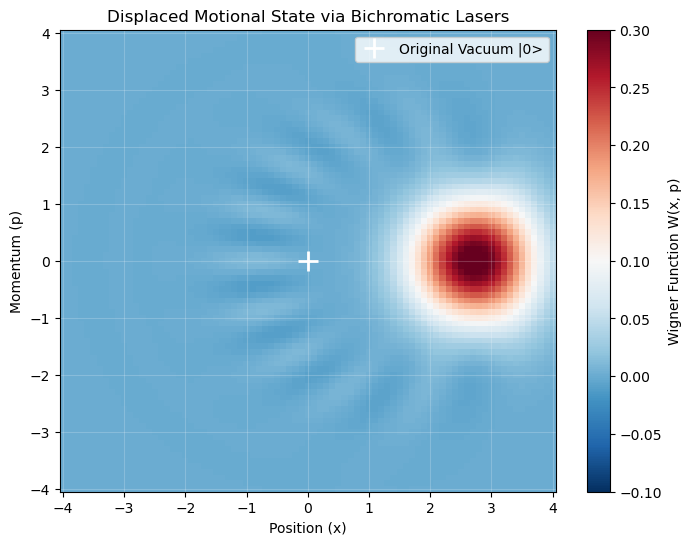

In [7]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [104]:
# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 19e5 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
# k_vec = (ẑ+ŷ) / √2
# ϵ_vec = ( x̂ + ŷ) / √2
ϵ_vec = ( ẑ - x̂ ) / √2

laser_intensity = 1e6 # Adjust this to push the ion faster/slower
# transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)


# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = -trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize(ion["g"] -  ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:50.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 1.81832e-12  2.87936e-12  4.45693e-12  …  3.22348e-11  2.68135e-11
 2.86874e-12  4.49128e-12  6.87028e-12     7.84756e-11  6.09775e-11
 4.42495e-12  6.84568e-12  1.03431e-11     1.85161e-10  1.36383e-10
 6.67285e-12  1.01951e-11  1.5205e-11      4.23003e-10  2.98875e-10
 9.83725e-12  1.4833e-11   2.18199e-11     9.36143e-10  6.40367e-10
 1.41761e-11  2.10775e-11  3.0553e-11   …  2.00925e-9   1.34005e-9
 1.99664e-11  2.92428e-11  4.17171e-11     4.18771e-9   2.73774e-9
 2.74815e-11  3.95955e-11  5.54965e-11     8.48635e-9   5.46056e-9
 3.69586e-11  5.22989e-11  7.18536e-11     1.67406e-8   1.06352e-8
 4.85612e-11  6.73524e-11  9.04338e-11     3.21789e-8   2.02327e-8
 ⋮                                      ⋱               ⋮
 3.68088e-11  5.20757e-11  7.15293e-11     1.67455e-8   1.0637e-8
 2.73712e-11  3.94289e-11  5.5251e-11      8.48948e-9   5.46171e-9
 1.9887e-11   2.91213e-11  4.15358e-11     4.18961e-9   2.73844e-9
 1.41202e-11  2.0991e-11   3.04222e-11  …  2

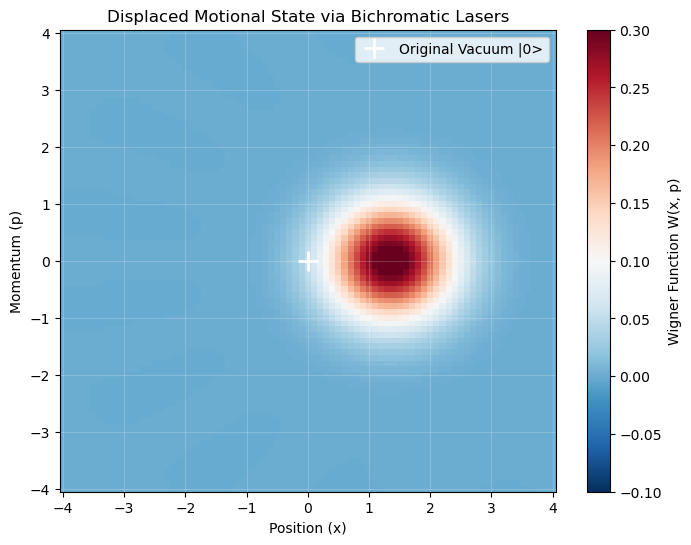

In [105]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [10]:

ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10


k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
# transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)


# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=π/2,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize( ion["g"]   + ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:50.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 5.91994e-6   1.0064e-5    …  1.57122e-6   1.00985e-6  6.34278e-7
 1.00619e-5   1.70037e-5      2.41579e-6   1.57293e-6  1.00017e-6
 1.67506e-5   2.81354e-5      3.6255e-6    2.39308e-6  1.54146e-6
 2.73142e-5   4.55956e-5      5.3107e-6    3.5564e-6   2.32214e-6
 4.36289e-5   7.23721e-5      7.59277e-6   5.16283e-6  3.4196e-6
 6.82665e-5   0.000112516  …  1.0595e-5    7.32156e-6  4.92306e-6
 0.000104641  0.000171344     1.44288e-5   1.01432e-5  6.92962e-6
 0.000157135  0.00025559      1.91761e-5   1.37283e-5  9.53767e-6
 0.000231169  0.000373465     2.4869e-5    1.81527e-5  1.28375e-5
 0.000333179  0.000534551     3.14678e-5   2.34506e-5  1.68996e-5
 ⋮                         ⋱                           ⋮
 1.34614e-5   1.88014e-5      0.000134057  8.65246e-5  5.46825e-5
 9.94385e-6   1.41483e-5      9.37506e-5   6.00701e-5  3.76887e-5
 7.17684e-6   1.03903e-5      6.4249e-5    4.08716e-5  2.54601e-5
 5.06124e-6   7.44804e-6   …  4.31463e-5   2.72523e-5  1.68567e

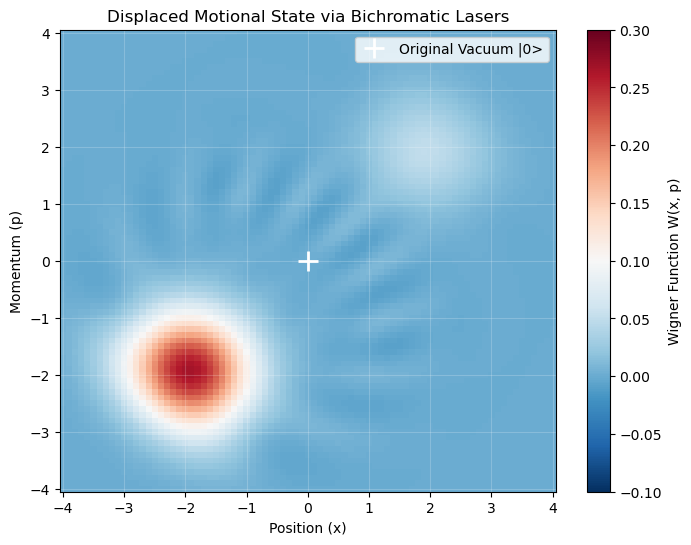

In [11]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [12]:

ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10


k_vec = (x̂ + ẑ) / √2
# k_vec = ẑ
ϵ_vec = (x̂ + ŷ) / √2
# ϵ_vec = ŷ

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
# transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13
trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap)


# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, ϕ=0,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, ϕ=π,I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize( ion["g"]  + im *  ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:50.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 1.30717e-6  2.1706e-6   3.53578e-6  …  3.58354e-6  2.19929e-6  1.32406e-6
 2.06091e-6  3.38445e-6  5.45029e-6     5.52548e-6  3.43009e-6  2.08804e-6
 3.16783e-6  5.14039e-6  8.17588e-6     8.29085e-6  5.21096e-6  3.21024e-6
 4.74603e-6  7.60223e-6  1.19289e-5     1.20995e-5  7.70822e-6  4.8105e-6
 6.92857e-6  1.0943e-5   1.69182e-5     1.71633e-5  1.10975e-5  7.02379e-6
 9.85301e-6  1.53241e-5  2.33067e-5  …  2.36474e-5  1.55423e-5  9.98949e-6
 1.36446e-5  2.08649e-5  3.11611e-5     3.16182e-5  2.1163e-5   1.38342e-5
 1.83932e-5  2.76046e-5  4.03933e-5     4.09835e-5  2.79978e-5  1.86483e-5
 2.41261e-5  3.54612e-5  5.07028e-5     5.1433e-5   3.59605e-5  2.44575e-5
 3.07793e-5  4.41935e-5  6.15343e-5     6.2395e-5   4.48014e-5  3.11942e-5
 ⋮                                   ⋱                          ⋮
 2.44575e-5  3.59605e-5  5.1433e-5      5.07028e-5  3.54612e-5  2.41261e-5
 1.86483e-5  2.79978e-5  4.09835e-5     4.03933e-5  2.76046e-5  1.83932e-5
 1.38342e-5 

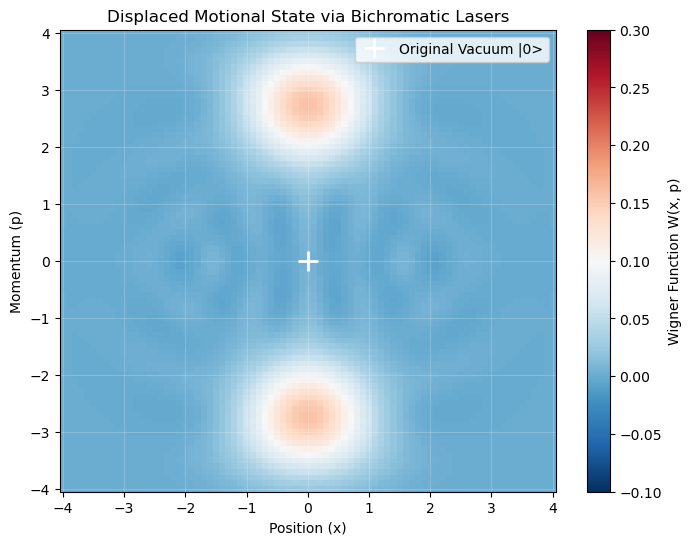

In [13]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
